# **Practice 24 - Prediction - k-Nearest Neighbors**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [1]:
library(class)  # for classification

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

<font color=red>Task 1.1</font>

We will be working with a dataset on appendicitis.

* Load the dataset using the link below:

  `https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/appendicitis.csv`

* Show the first few lines to confirm you have imported the data correctly

In [2]:
# Load the dataset
data <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/appendicitis.csv")

# Show the first few lines
head(data)

,Age,BMI,isFemale,Height,Weight,Length_of_Stay,Has_Migratory_Pain,Has_Right_Abd_Pain,Has_Coughing_Pain,Has_Nausea,⋯,WBC_Count,Neutrophil_Percentage,Neutrophilia,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,Dysuria,Diagnosis
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,12.68,16.9,1,148,37.0,3,0,1,0,0,⋯,7.7,68.2,0,5.27,14.8,12.2,254,0,0,appendicitis
2,14.10,31.9,0,147,69.5,2,1,1,0,0,⋯,8.1,64.8,0,5.26,15.7,12.7,151,3,1,no appendicitis
3,14.14,23.3,1,163,62.0,4,0,1,0,0,⋯,13.2,74.8,0,3.98,11.4,12.2,300,3,0,no appendicitis
4,16.37,20.6,1,165,56.0,3,1,1,0,1,⋯,11.4,63.0,0,4.64,13.6,13.2,258,0,1,no appendicitis
5,11.08,16.9,1,163,45.0,3,0,1,1,1,⋯,8.1,44.0,0,4.44,12.6,13.6,311,0,0,appendicitis
6,11.05,30.7,0,121,45.0,3,1,1,1,1,⋯,9.5,71.4,0,4.96,12.5,13.3,249,63,0,no appendicitis


<br>

<font color=red>Task 1.2</font>

* Describe the dataset's attributes (e.g., number of variables, number of observations, ets.)

  Note that several variables are binary (0-1). For example, for the variable `isFemale`, a value of 1 indicates a female and a value of 0 indicates male.

The dataset contains multiple observations (rows) and variables (columns), where each row represents a patient and each column represents a clinical attribute. Several variables are binary (0 and 1), such as is female, where 1 indicates female and 0 indicates male.

<br>

<font color=red>Task 1.3</font>

* What are the unique values of the `Diagnosis` variable?

In [3]:
unique(data$Diagnosis)

[1] "appendicitis"    "no appendicitis"

<br>

<br>

<br>

---

####<font color=red>Task 2</font>

<font color=red>Task 2.1</font>

We will develop k-nearest neighbors models to predict `Diagnosis` as our response (y-variable) using other variables in the dataset as predictors (x-variables)

* Partition your dataset into a training and testing set

  * Include all variables (except `Diagnosis`) in your training dataset `train_data` and testing dataset `test_data`

  * The variable `Diagnosis` will be our response (`train_labels` and `test_labels`)

In [6]:
# size of training dataset
training_data_size <- round(0.7 * nrow(data))

# size of testing dataset
testing_data_size <- nrow(data) - training_data_size

# sample indexes for the training data
training_sample <- sample(1:nrow(data), training_data_size)

# create datasets
train_data <- data[training_sample, -which(names(data) == "Diagnosis")]
test_data  <- data[-training_sample, -which(names(data) == "Diagnosis")]

# labels
train_labels <- data[training_sample, "Diagnosis"]
test_labels  <- data[-training_sample, "Diagnosis"]

In [9]:
# sample our training data
train_data <- data[training_sample, names(data)[names(data) != "Diagnosis"]]

# training labels
train_labels <- data[training_sample, "Diagnosis"]

# remaining rows are the testing data
test_data <- data[-training_sample, names(data)[names(data) != "Diagnosis"]]

# testing labels
test_labels <- data[-training_sample, "Diagnosis"]

<br>

<br>

<br>

---

####<font color=red>Task 3</font>

<font color=red>Task 3.1</font>

* Visualize the relationship between `Diagnosis` and `Neutrophil_Percentage` (white blood cell count) using a boxplot

  Note: Although `Diagnosis` is our y-variable for prediction, `Diagnosis` should be on the x-axis for the boxplot

* What are your observations? Does it appear that `Neutrophil_Percentage` would be helpful in predicting appendicitis? Explain your answer.

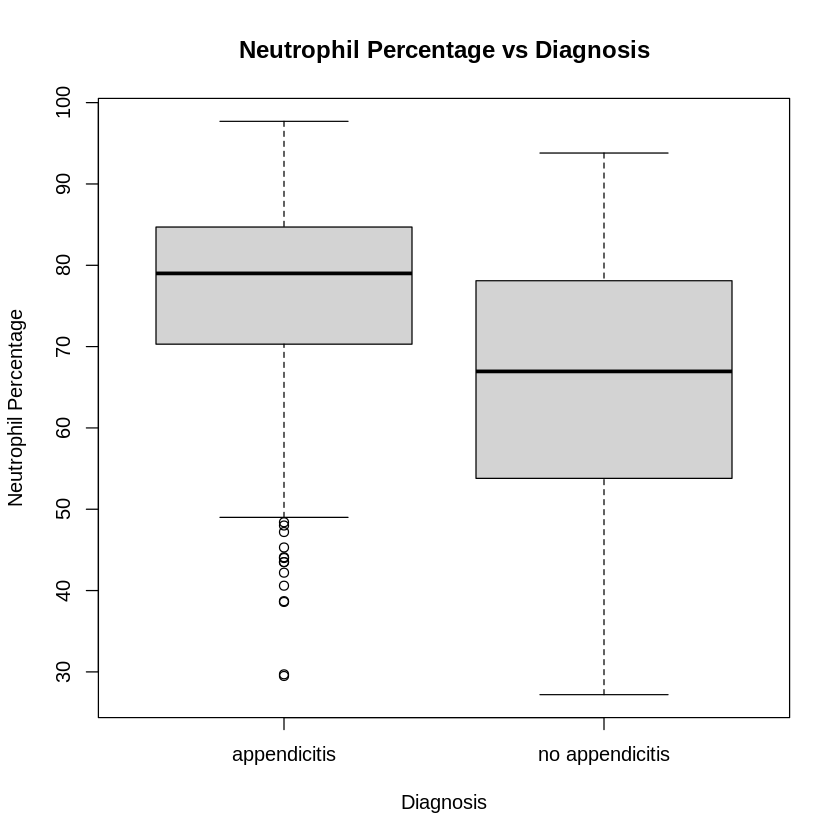

In [12]:
boxplot(Neutrophil_Percentage ~ Diagnosis, data = data,
        xlab = "Diagnosis",
        ylab = "Neutrophil Percentage",
        main = "Neutrophil Percentage vs Diagnosis")

Individuals with appendicitis tend ot have higher neutrophil percentage, suggesting neutrophil percentage would be a useful predictor of appendicitis.

<br>

<font color=red>Task 3.2</font>

* Train a k-nearest neighbors algorithm to predict `Diagnosis` using ONLY the variable `Neutrophil_Percentage` and `k = 100` nearest neighbors
  
    ```
    # Hint:
    knn(train = train_data["Neutrophil_Percentage"],
        test  = test_data["Neutrophil_Percentage"], ...
    ```

* What is the accuracy of your predictions on the testing set?

In [13]:
# number of neighbors
k <- 100

# "train" k-nearest neighbors and predict
predictions <- knn(train = train_data["Neutrophil_Percentage"],  # train predictors (x-variable)
                  test  = test_data["Neutrophil_Percentage"],    # testing predictors (x-varibales)
                  cl = train_labels,                             # true training labels (y-variable)
                  k = k)

# calculate prediction accuracy
accuracy <- sum(predictions == test_labels) / length(test_labels)
print(paste("Accuracy:", round(accuracy*100, 2), "%"))

[1] "Accuracy: 69.95 %"


<br>

<font color=red>Task 3.3</font>

* Visualize the relationship between `Diagnosis` and `Height` using a boxplot

  Note: Although `Diagnosis` is our y-variable for prediction, `Diagnosis` should be on the x-axis for the boxplot

* What are your observations? Does it appear that `Height` would be helpful in predicting appendicitis? Explain your answer.

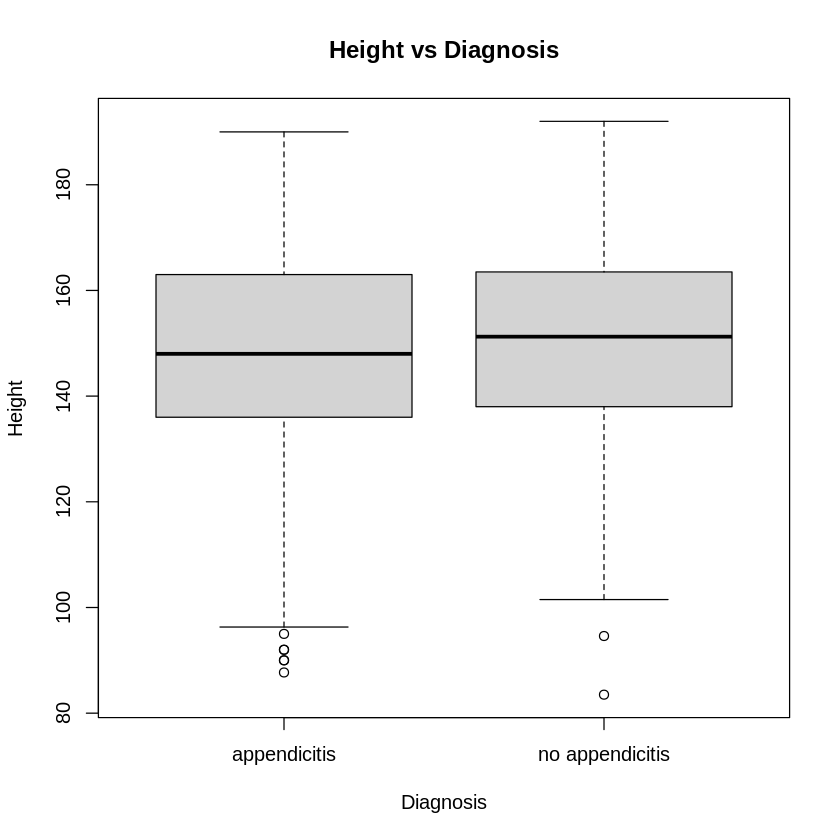

In [15]:
boxplot(Height ~ Diagnosis, data = data,
        xlab = "Diagnosis",
        ylab = "Height",
        main = "Height vs Diagnosis")

Individuals with appendicitis tend to be slightly shorter in Height. However, the difference is very very small. Height is likely not a good predictor of appendicitis.

<br>

<font color=red>Task 3.4</font>

* Train a k-nearest neighbors algorithm to predict `Diagnosis` using ONLY the variable `Height` and `k = 100` nearest neighbors
  
    ```
    # Hint:
    knn(train = train_data["Height"],
        test  = test_data["Height"], ...
    ```

* What is the accuracy of your predictions on the testing set?

In [16]:
# number of neighbors
k <- 100

# "train" k-nearest neighbors and predict
predictions <- knn(train = train_data["Height"],  # train predictors (x-variable)
                  test  = test_data["Height"],    # testing predictors (x-varibales)
                  cl = train_labels,                             # true training labels (y-variable)
                  k = k)

# calculate prediction accuracy
accuracy <- sum(predictions == test_labels) / length(test_labels)
print(paste("Accuracy:", round(accuracy*100, 2), "%"))

[1] "Accuracy: 55.96 %"


<br>

<font color=red>Task 3.5</font>

* Compare the accuracies from Tasks 3.2 and 3.4 and relate the comparison to what you visually observed in Tasks 3.1 and 3.3.

Neutrophil percentage produces a higher acuracy than height for predicting appendicitis. This is an agreement with our observation from the boxplots, which is a stronger relationship between neutrophil precentage and the presence of appendicitis.  

<br>

<br>

<br>

---

####<font color=red>Task 4</font>

<font color=red>Task 4.1</font>

* Train a k-nearest neighbors algorithm to predict `Diagnosis` using ALL  variables
  
    ```
    # Hint:
    knn(train = train_data,
        test  = test_data, ...
    ```

* What is the accuracy of your predictions on the testing set?

In [17]:
# number of neighbors
k <- 100

# "train" k-nearest neighbors and predict
predictions <- knn(train = train_data,  # train predictors (x-variable)
                  test  = test_data,    # testing predictors (x-varibales)
                  cl = train_labels,                             # true training labels (y-variable)
                  k = k)

# calculate prediction accuracy
accuracy <- sum(predictions == test_labels) / length(test_labels)
print(paste("Accuracy:", round(accuracy*100, 2), "%"))

[1] "Accuracy: 65.28 %"


<br>

<font color=red>Task 4.2</font>

* Did your accuracy improve over the accuracy from Task 3.2? Task 3.4?

* Speculate as to why your accuracy increased/decreased

The accuracy when including all variables was larger than including height and smaller than including only neutrophil percentage. There are a few reasons why the accuracy decreased when compared to only including neutrophil percentage. Reasons include:

 * We need to search for a more optimal `k`
 * We have inlcuded too many variables that do not have a strong relationship with `Diagnosis`
 * We do not have enough observations to make predications with this many variables.  

<br>

<br>

<br>

---

####<font color=red>Task 5</font>

<font color=red>Task 5.1</font>

* Maximize your prediction accuracy for `Diagnosis` by

  * using different values for `k`

  * including different sets of (useful) variables

In [19]:
# store accuracies
accuracies <- c()

# k values to test
k_search <- 1:100

for(neighbors in k_search){

  set.seed(1)

  # set k
  k <- neighbors

  # train model using ALL predictors except Diagnosis
  predictions <- knn(
    train = train_data,
    test  = test_data,
    cl    = train_labels,
    k     = k
  )

  # calculate accuracy
  accuracy <- sum(predictions == test_labels) / length(test_labels)

  # store accuracy
  accuracies <- c(accuracies, accuracy)
}

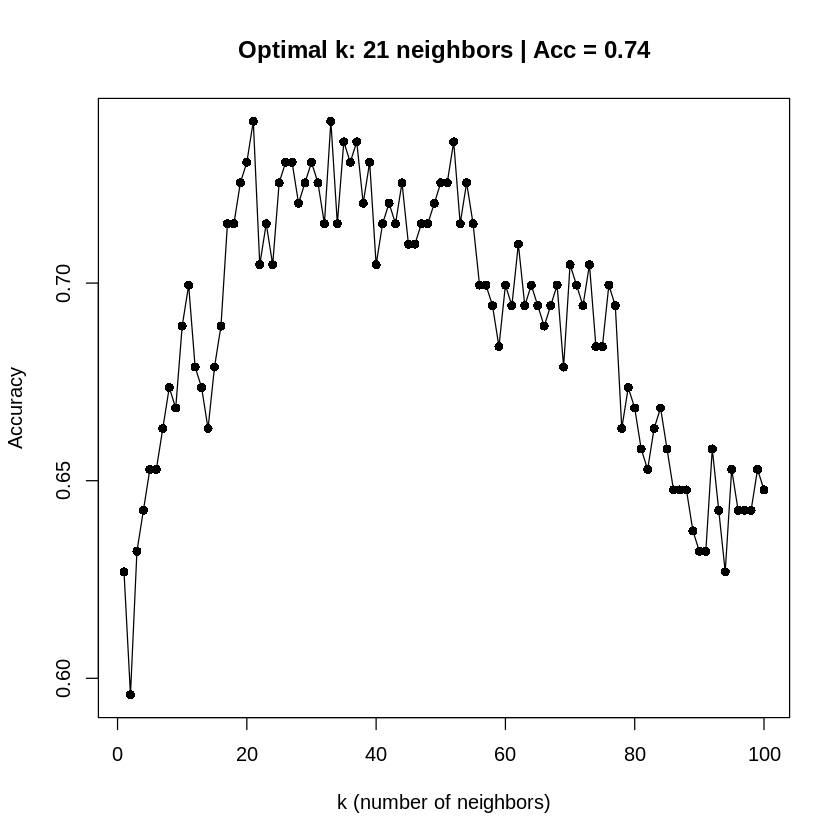

In [20]:
# extract optimal k that maximizes accuracy
optimal_k <- k_search[which.max(accuracies)]

# optimal accuracy
max_acc <- round(max(accuracies), 2)

# plot accuracies over values of k
plot(k_search, accuracies, type = "o", pch = 16,
     xlab = "k (number of neighbors)",
     ylab = "Accuracy",
     main = paste("Optimal k:", optimal_k, "neighbors | Acc =", max_acc))

<br>

<br>